# Distortion Amplitudes vs Injection Redshift

Generates `pde_mu_y_vs_zh.pdf` (Figure 2 in paper).

Left: mu/drho in the mu-era. Right: 4y/drho in the y-era.

In [1]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import sys
from pathlib import Path

import matplotlib
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize as sp_minimize

## Run PDE sweep

In [2]:
# Add project root to path
PROJECT_ROOT = Path.cwd().parent.parent

from spectroxide import apply_style, C, SINGLE_COL, strip_gbb
from spectroxide.plot_params import LW, LW_THIN, MS_SMALL, ANNOT_SIZE
from spectroxide.solver import run_sweep
from spectroxide.greens import (
    j_bb_star, j_mu, j_y, mu_shape, y_shape, g_bb,
    KAPPA_C,
)

import matplotlib.pyplot as plt

apply_style()

FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(exist_ok=True)

## Extract spectra via three-component GF fit

In [3]:
z_injections = np.geomspace(2e3, 3e6, 40)
delta_rho = 1e-5

print(f"Running PDE sweep: {len(z_injections)} redshifts, Δρ/ρ = {delta_rho:.0e}")
data = run_sweep(
    delta_rho=delta_rho,
    z_injections=z_injections,
    n_points=4000,
    production_grid=True,
    timeout=1200,
)
results = data["results"]
z_h = np.array([r["z_h"] for r in results])
x_spectra = [np.array(r["x"]) for r in results]
dn_spectra = [np.array(r["delta_n"]) for r in results]

# ── Three-component GF spectral fit (same as visibility extraction) ─
def _gf_model(x, j_mu_val, j_bb_star_val, j_y_val):
    """Three-component Green's function ansatz (per unit Δρ/ρ)."""
    return ((3.0 / KAPPA_C) * j_mu_val * j_bb_star_val * mu_shape(x)
            + 0.25 * j_y_val * y_shape(x)
            + 0.25 * (1.0 - j_mu_val * j_bb_star_val - j_y_val) * g_bb(x))


N_INTERP = 2000
j_mu_pde = np.zeros(len(z_h))
j_bb_star_pde = np.zeros(len(z_h))

for i in range(len(z_h)):
    x_i = x_spectra[i]
    dn_i = dn_spectra[i]

    # Interpolate to fine uniform grid for robust fitting
    x_fine = np.linspace(max(x_i.min(), 0.5), min(x_i.max(), 20), N_INTERP)
    cs = CubicSpline(x_i, dn_i, extrapolate=False)
    dn_fine = np.nan_to_num(cs(x_fine), nan=0.0)

    # NC-strip
    dn_nc, _ = strip_gbb(x_fine, dn_fine)

    # J_y from Chluba's independent fit (fixed)
    j_y_i = j_y(z_h[i])

    def _residual(params, j_y_fixed=j_y_i, x=x_fine, dn_target=dn_nc):
        jm, jb = params
        model = _gf_model(x, jm, jb, j_y_fixed) * delta_rho
        model_nc, _ = strip_gbb(x, model)
        return np.sum((x**3 * (model_nc - dn_target))**2)

    res = sp_minimize(
        _residual,
        [j_mu(z_h[i]), j_bb_star(z_h[i])],
        bounds=[(0, 1), (0, 1)],
        method="L-BFGS-B",
    )
    j_mu_pde[i] = res.x[0]
    j_bb_star_pde[i] = res.x[1]
# Compute μ/Δρ and 4y/Δρ from fitted visibility functions
mu_over_drho = (3.0 / KAPPA_C) * j_mu_pde * j_bb_star_pde
four_y_over_drho = j_y(z_h)  # J_y = 4y/Δρ by definition

Running PDE sweep: 40 redshifts, Δρ/ρ = 1e-05


## Plot


μ-era (2e5 < z < 2e6):
  μ/Δρ range: 0.670 -- 1.371
  max deviation from GF: 0.0003

y-era (z < 5e4):
  4y/Δρ range: 0.6342 -- 0.9998

Saved: /home/bakerem/cosmoxide/notebooks/figures/pde_mu_y_vs_zh.pdf


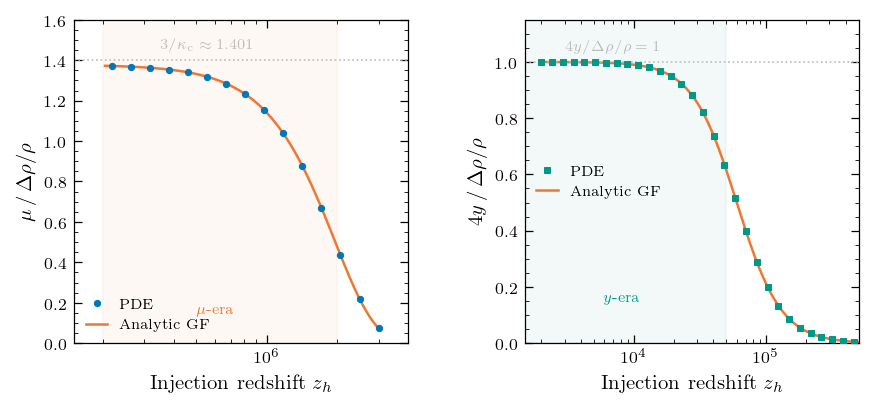

In [4]:
# Analytic GF predictions (smooth curves)
z_smooth = np.geomspace(z_h.min(), z_h.max(), 300)
mu_gf = np.array([1.401 * j_bb_star(z) * j_mu(z) for z in z_smooth])
four_y_gf = np.array([j_y(z) for z in z_smooth])
# Print summary
print(f"\nμ-era (2e5 < z < 2e6):")
mask = (z_h >= 2e5) & (z_h <= 2e6)
print(f"  μ/Δρ range: {mu_over_drho[mask].min():.3f} -- {mu_over_drho[mask].max():.3f}")
print(f"  max deviation from GF: {np.max(np.abs(mu_over_drho[mask] - np.array([1.401*j_bb_star(z)*j_mu(z) for z in z_h[mask]]))):.4f}")

print(f"\ny-era (z < 5e4):")
mask_y = z_h <= 5e4
print(f"  4y/Δρ range: {four_y_over_drho[mask_y].min():.4f} -- {four_y_over_drho[mask_y].max():.4f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(SINGLE_COL * 2, 2.8))
fig.subplots_adjust(wspace=0.35)

# --- Left panel: μ/Δρ vs z_h (μ-era focus) ---
mask_mu = z_h >= 2e5
ax1.semilogx(z_h[mask_mu], mu_over_drho[mask_mu], "o", color=C["blue"],
             ms=MS_SMALL, lw=LW, label="PDE", zorder=5, mew=0.5)
z_smooth_mu = z_smooth[z_smooth >= 2e5]
mu_gf_mu = np.array([1.401 * j_bb_star(z) * j_mu(z) for z in z_smooth_mu])
ax1.semilogx(z_smooth_mu, mu_gf_mu, "-", color=C["orange"], lw=LW,
             label="Analytic GF")
ax1.axhline(1.401, color=C["gray"], ls=":", lw=LW_THIN)
ax1.text(3.5e5, 1.44, r"$3/\kc \approx 1.401$", fontsize=ANNOT_SIZE,
         color=C["gray"], va="bottom")
# Era shading
ax1.axvspan(2e5, 2e6, alpha=0.05, color=C["orange"])
ax1.text(6e5, 0.15, r"$\mu$-era", fontsize=ANNOT_SIZE, color=C["orange"],
         ha="center")

ax1.set_xlabel(r"Injection redshift $z_h$")
ax1.set_ylabel(r"$\mu \,/\, \drho$")
ax1.set_xlim(1.5e5, 4e6)
ax1.set_ylim(0, 1.6)
ax1.legend(loc="lower left", fontsize=ANNOT_SIZE)

# --- Right panel: 4y/Δρ vs z_h (y-era focus) ---
mask_y = z_h <= 5e5
ax2.semilogx(z_h[mask_y], four_y_over_drho[mask_y], "s", color=C["teal"],
             ms=MS_SMALL, lw=LW, label="PDE", zorder=5, mew=0.5)
ax2.semilogx(z_smooth, four_y_gf, "-", color=C["orange"], lw=LW,
             label="Analytic GF")
ax2.axhline(1.0, color=C["gray"], ls=":", lw=LW_THIN)
ax2.text(3e3, 1.03, r"$4y/\drho = 1$", fontsize=ANNOT_SIZE,
         color=C["gray"], va="bottom")
# Era shading
ax2.axvspan(1e3, 5e4, alpha=0.05, color=C["teal"])
ax2.text(8e3, 0.15, r"$y$-era", fontsize=ANNOT_SIZE, color=C["teal"],
         ha="center")

ax2.set_xlabel(r"Injection redshift $z_h$")
ax2.set_ylabel(r"$4y \,/\, \drho$")
ax2.set_xlim(1.5e3, 5e5)
ax2.set_ylim(0, 1.15)
ax2.legend(loc="center left", fontsize=ANNOT_SIZE)

outpath = FIG_DIR / 'pde_mu_y_vs_zh.pdf'
fig.savefig(outpath)
print(f"\nSaved: {outpath}")